In [1]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# NLP
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Machine Learning
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# Download NLP resources
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/adnanaltimeemy/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/adnanaltimeemy/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [2]:
# Load Watchlist dataset
df = pd.read_csv("Watchlist.csv")

# Display first rows
df.head()

,Name,"""Year"""
0,Mission: Impossible – Dead Reckoning Part 2,2025
1,Wicked,2024
2,Inside Out 2,2024
3,Furiosa: A Mad Max Saga,2024
4,The Wild Robot,2024


In [3]:
# Dataset information
df.info()

# Shape of dataset
print("Dataset Shape:", df.shape)

# Missing values
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 439 entries, 0 to 438
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Name     439 non-null    str  
 1    "Year"  439 non-null    int64
dtypes: int64(1), str(1)
memory usage: 13.6 KB
Dataset Shape: (439, 2)


Name       0
 "Year"    0
dtype: int64

In [4]:
# Remove duplicate rows
df = df.drop_duplicates()

# Fill missing values
df = df.fillna("")

# View column names
df.columns

Index(['Name', ' "Year"'], dtype='str')

In [5]:
# Select text columns automatically
text_columns = df.select_dtypes(include=['object']).columns

# Combine all text columns
df["combined_text"] = df[text_columns].apply(
    lambda x: " ".join(x.astype(str)), axis=1
)

df[["combined_text"]].head()

/var/folders/88/w4w1n8l12kd_z42_6mrnndmw0000gn/T/ipykernel_87292/152448126.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_columns = df.select_dtypes(include=['object']).columns


,combined_text
0,Mission: Impossible – Dead Reckoning Part 2
1,Wicked
2,Inside Out 2
3,Furiosa: A Mad Max Saga
4,The Wild Robot


In [6]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    # Lowercase
    text = text.lower()
    
    # Remove special characters
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    
    # Tokenization
    words = text.split()
    
    # Remove stopwords and lemmatize
    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]
    
    return " ".join(words)


df["clean_text"] = df["combined_text"].apply(clean_text)

df[["clean_text"]].head()

,clean_text
0,mission impossible dead reckoning part
1,wicked
2,inside
3,furiosa mad max saga
4,wild robot


In [7]:
tfidf = TfidfVectorizer(
    max_features=5000
)

X = tfidf.fit_transform(df["clean_text"])

print("TF-IDF Shape:", X.shape)

TF-IDF Shape: (439, 668)


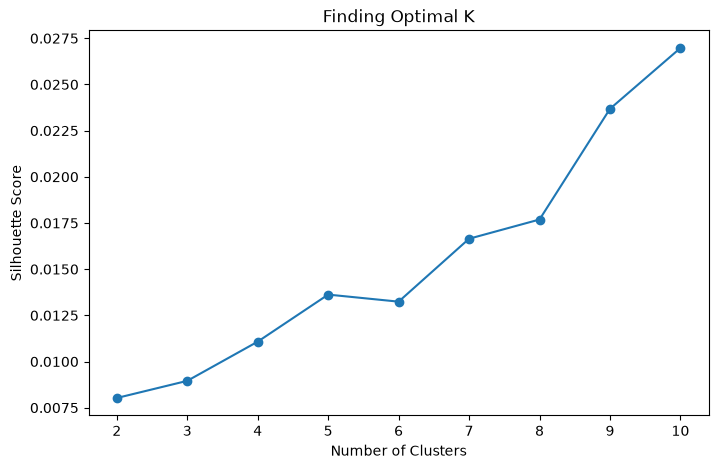

In [8]:
silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = kmeans.fit_predict(X)
    
    score = silhouette_score(X, labels)
    silhouette_scores.append(score)


plt.figure(figsize=(8,5))
plt.plot(range(2,11), silhouette_scores, marker="o")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Finding Optimal K")
plt.show()

In [9]:
# Choose number of clusters
k = 5

kmeans = KMeans(
    n_clusters=k,
    random_state=42,
    n_init=10
)

df["Cluster"] = kmeans.fit_predict(X)

df.head()

,Name,"""Year""",combined_text,clean_text,Cluster
0,Mission: Impossible – Dead Reckoning Part 2,2025,Mission: Impossible – Dead Reckoning Part 2,mission impossible dead reckoning part,4
1,Wicked,2024,Wicked,wicked,4
2,Inside Out 2,2024,Inside Out 2,inside,4
3,Furiosa: A Mad Max Saga,2024,Furiosa: A Mad Max Saga,furiosa mad max saga,4
4,The Wild Robot,2024,The Wild Robot,wild robot,4


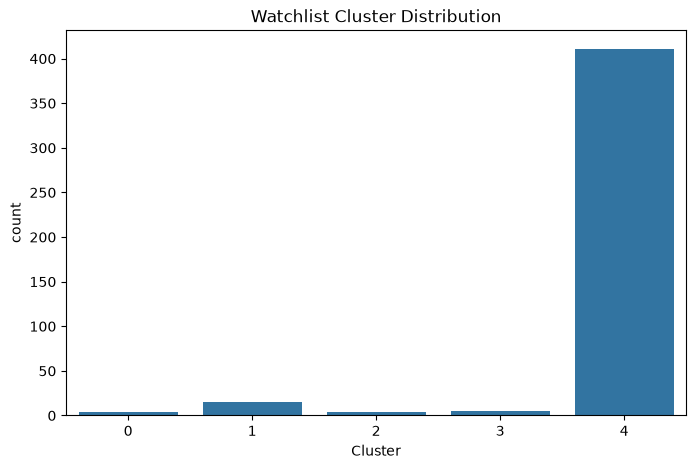

In [10]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="Cluster",
    data=df
)

plt.title("Watchlist Cluster Distribution")
plt.show()

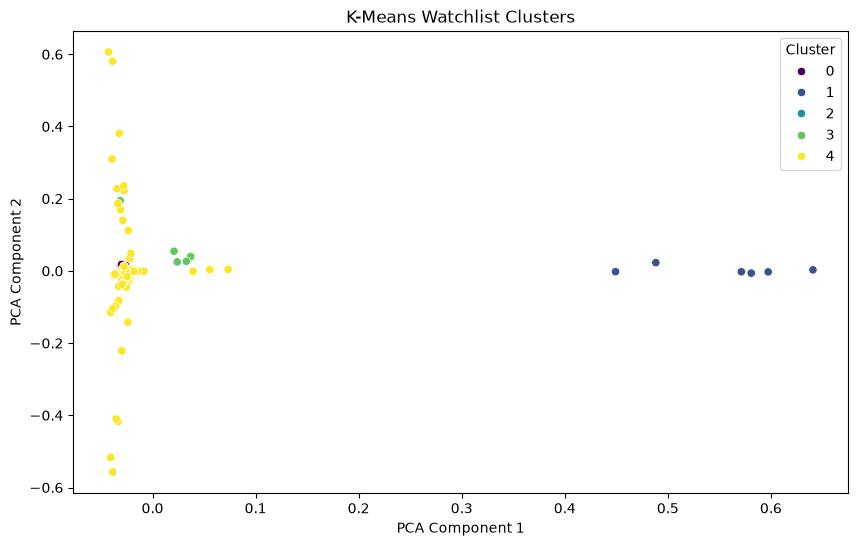

In [11]:
# Reduce dimensions
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X.toarray())


plt.figure(figsize=(10,6))

sns.scatterplot(
    x=X_pca[:,0],
    y=X_pca[:,1],
    hue=df["Cluster"],
    palette="viridis"
)

plt.title("K-Means Watchlist Clusters")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")

plt.show()

In [12]:
for cluster in range(k):
    print("\nCluster:", cluster)
    
    display(
        df[df["Cluster"] == cluster]
        .head(10)
    )


Cluster: 0


,Name,"""Year""",combined_text,clean_text,Cluster
81,Cocaine Cowboys,2006,Cocaine Cowboys,cocaine cowboy,0
227,Drugstore Cowboy,1989,Drugstore Cowboy,drugstore cowboy,0
286,Urban Cowboy,1980,Urban Cowboy,urban cowboy,0
335,Midnight Cowboy,1969,Midnight Cowboy,midnight cowboy,0



Cluster: 1


,Name,"""Year""",combined_text,clean_text,Cluster
50,Searching for Sugar Man,2012,Searching for Sugar Man,searching sugar man,1
64,Ip Man,2008,Ip Man,ip man,1
65,Man on Wire,2008,Man on Wire,man wire,1
87,Cinderella Man,2005,Cinderella Man,cinderella man,1
89,Grizzly Man,2005,Grizzly Man,grizzly man,1
102,Man on Fire,2004,Man on Fire,man fire,1
131,"Family Man, The",2000,"Family Man, The",family man,1
170,Dead Man,1995,Dead Man,dead man,1
282,"Elephant Man, The",1980,"Elephant Man, The",elephant man,1
317,The Man with the Golden Gun,1974,The Man with the Golden Gun,man golden gun,1



Cluster: 2


,Name,"""Year""",combined_text,clean_text,Cluster
8,The Boy and the Heron,2023,The Boy and the Heron,boy heron,2
111,About a Boy,2002,About a Boy,boy,2
140,Boys Don't Cry,1999,Boys Don't Cry,boy cry,2
179,Tommy Boy,1995,Tommy Boy,tommy boy,2



Cluster: 3


,Name,"""Year""",combined_text,clean_text,Cluster
10,Top Gun: Maverick,2023,Top Gun: Maverick,top gun maverick,3
189,Naked Gun 33 1/3: The Final Insult,1994,Naked Gun 33 1/3: The Final Insult,naked gun final insult,3
210,"Naked Gun 2 1/2, The",1991,"Naked Gun 2 1/2, The",naked gun,3
230,Star Trek V: The Final Frontier,1989,Star Trek V: The Final Frontier,star trek v final frontier,3
236,Young Guns,1988,Young Guns,young gun,3



Cluster: 4


,Name,"""Year""",combined_text,clean_text,Cluster
0,Mission: Impossible – Dead Reckoning Part 2,2025,Mission: Impossible – Dead Reckoning Part 2,mission impossible dead reckoning part,4
1,Wicked,2024,Wicked,wicked,4
2,Inside Out 2,2024,Inside Out 2,inside,4
3,Furiosa: A Mad Max Saga,2024,Furiosa: A Mad Max Saga,furiosa mad max saga,4
4,The Wild Robot,2024,The Wild Robot,wild robot,4
5,September 5,2024,September 5,september,4
6,Oppenheimer,2023,Oppenheimer,oppenheimer,4
7,Air,2023,Air,air,4
9,Dungeons & Dragons: Honor Among Thieves,2023,Dungeons & Dragons: Honor Among Thieves,dungeon dragon honor among thief,4
11,The Bob's Burgers Movie,2022,The Bob's Burgers Movie,bob burger movie,4


In [13]:
df.to_csv(
    "Watchlist_KMeans_NLP_Clusters.csv",
    index=False
)

print("File saved successfully!")

File saved successfully!
